In [1]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [2]:
# In Jupyter, __file__ is not defined. Use the notebook's working directory.
file_path = Path().resolve()
root_dir = file_path.parent
map_path = root_dir / "data" / "map.png"

print(f"Root directory: {root_dir}")
print(f"Map path: {map_path}")

Root directory: D:\rober\Documents\GitHub
Map path: D:\rober\Documents\GitHub\data\map.png


In [3]:
patch_sizes = [256, 384, 512, 640]
patch_height = patch_sizes[2]
patch_width = int(patch_height * 4/3)  # 4:3 aspect ratio

stride_sizes = [1, 2, 4, 8]
stride_size = stride_sizes[1]
stride_y = patch_height // stride_size
stride_x = patch_width // stride_size

In [4]:
from map_processing.generate_patches import main as generate_patches

patch = {
    "height": patch_height,
    "width": patch_width,
    "stride_y": stride_y,
    "stride_x": stride_x,
}

patches, positions = generate_patches(patch, draw_patches=True)

ModuleNotFoundError: No module named 'map_processing'

In [ ]:
output_dir = Path("./patches")
output_dir.mkdir(parents=True, exist_ok=True)

for idx, patch in enumerate(patches):
    out_path = output_dir / f"patch_{idx:03d}.png"
    cv2.imwrite(str(out_path), patch)

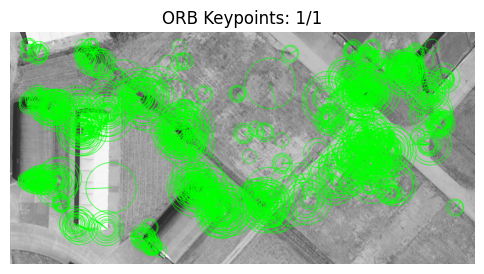

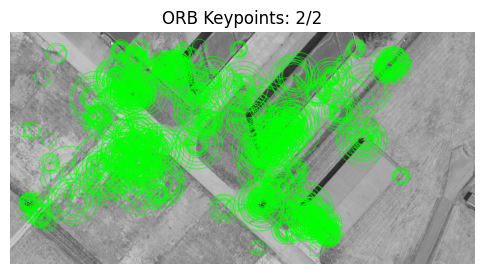

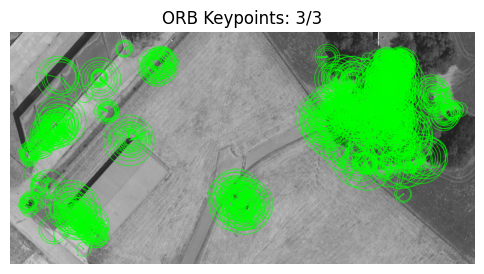

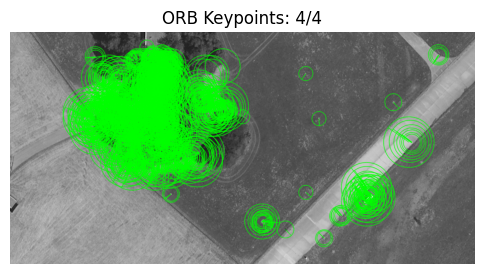

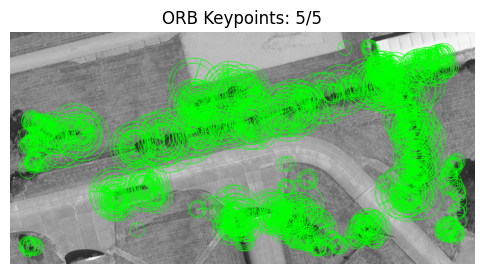

In [ ]:
orb = cv2.ORB_create(nfeatures=1000)

lb = 20
ub = lb + 5

patch_descriptors = []

for i, patch_img in enumerate(patches[lb:ub]):

    keypoints, descriptors = orb.detectAndCompute(patch_img, None)
    patch_descriptors.append({
        "keypoints": keypoints,
        "descriptors": descriptors,
        "position": positions[i],
    })

    # Draw keypoints on the image
    img_with_kp = cv2.drawKeypoints(
        patch_img, keypoints, None,
        color=(0, 255, 0), flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )

    # Display using matplotlib
    plt.figure(figsize=(6, 6))
    plt.title(f"ORB Keypoints: {i + 1}/{len(patch_descriptors)}")
    plt.imshow(img_with_kp)
    plt.axis('off')
    plt.show()


In [ ]:
train_images_dir = root_dir / "data" / "train_data" / "train_images"

train_images = []

for img_path in train_images_dir.glob("*.JPG"):
    
    img = Image.open(img_path)
    if img is not None:
        height, width = img.size
        aspect_ratio = width / height
        
        train_images.append({
            "path": img_path,
            "height": height,
            "width": width,
            "aspect_ratio": aspect_ratio
        })
    else:
        print("Image not found or failed to load.")


In [ ]:
train_cam = root_dir / "data" / "train_data" / "train_cam.csv"

train_cam_df = pd.read_csv(train_cam)

for idx, row in train_cam_df.iterrows():
    
    train_images[idx]["focal_len"] = {
        "x": row["fx"],
        "y": row["fy"]
    }

In [ ]:
alt = 200 # m
pixel_size = 2.4 * 10**-3  # mm, typical pixel size for UAV cameras


"""
GSD = (altitude * pixel_size) / focal_length
    GSD in m / pixel
    altitude in m
    pixel_size in mm / pixel
    focal_length in mm
"""

for i, img in enumerate(train_images):
    
    img["gsd"] = {
        "x": alt * pixel_size / img["focal_len"]["x"],
        "y": alt * pixel_size / img["focal_len"]["y"]
    }

    print(f"Image {i + 1}/{len(train_images)} - gsd_x: {img['gsd']['x']} m, gsd_y: {img['gsd']['y']} m")

Image 1/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 2/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 3/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 4/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 5/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 6/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 7/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 8/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 9/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 10/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 11/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 12/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-05 m
Image 13/305 - gsd_x: 7.180728717296522e-05 m, gsd_y: 7.143533184389256e-